# Stipulation snap-back, frame-level commitment, and articulation-for-scale substitution
**2026-07-06** — results notebook for the E2 (name-commitment) program and its performance corollaries.
Companion notes: `notes/2026-07-05__tacitness-scaling-law-and-confounder-battery.md` (PARTs III–VI).
Data: `notebooks/data/two_faces_20260702/` (stipulation{,2,_cw}, probe_clustered_suppress, name_dimension_codes,
e2_salience_covariate, articulation_substitution_rates, t10b_cell_persistence).

**The instrument.** E2 stipulation: tell the reader *"for THIS task only, '⟨name⟩' means exactly: ⟨orthogonal
mechanical rule⟩"* and measure **compliance** (AUC vs the deviant rule's truth) vs **snap-back** (AUC vs the real
concept). The critical **nonce control** runs the same deviant rule under an invented name ("the smorbex property"):

> **name commitment** ≡ suppress = compliance(nonce) − compliance(real name) — content bound to the word that an
> explicit in-prompt definition cannot overwrite. (Construct-level lexical-Stroop; the positive, non-eliminative
> signature of enculturated meaning. The control matters: at 1B, compliance ≈ chance under BOTH names — an
> instruction-floor artifact the control caught before it became a false positive.)

In [1]:
import json, glob
import numpy as np
import matplotlib.pyplot as plt
D = "data/two_faces_20260702"
STRONG = ["meta-llama/Llama-3.1-8B-Instruct", "Qwen/Qwen2.5-7B-Instruct", "google/gemma-2-9b-it"]
FILES = {"humor": "stipulation2_humor.json", "math": "stipulation2_math.json", "cw": "stipulation_cw.json"}
def rows_for(T):
    d = json.load(open(f"{D}/{FILES[T]}"))
    out = {}
    for r in STRONG:
        for gi, v in d.get(r, {}).items():
            if isinstance(v, dict) and v.get("stipNonce_compliance") is not None and v.get("stip_compliance") is not None:
                out.setdefault(gi, []).append(v["stipNonce_compliance"] - v["stip_compliance"])
    return out
sup = {T: rows_for(T) for T in FILES}
print({T: f"{len(v)} metrics" for T, v in sup.items()})

{'humor': '59 metrics', 'math': '21 metrics', 'cw': '46 metrics'}


## 1. The three-domain dissociation (strong readers, 2 model families)

**What this section measures.** We test whether models will obey an explicit in-prompt instruction to judge a text by a *fake* mechanical rule when that fake rule is presented under a *real* metric's name (e.g., "for this task, 'setup-punchline mismatch' means exactly: count the words"). The question: does the name carry meaning that resists being overwritten?

**The measurement.** For each metric we compute **suppress** = compliance(nonce name) − compliance(real name). A positive value means the model complied *less* with the deviant rule when it was presented under the real name than under an invented name ("smorbex property") — the real name blocked the instruction.

**How to read the figure.** Left panel: pooled suppress across all metrics in each domain. Humor shows positive suppress (+0.033): models resist redefining humor terms. CW and math show near-zero (−0.006, −0.005): models happily accept the stipulated definition. Right panel: per-reader results with honest p-values (probe-clustered to account for metric non-independence). Only humor readers show consistent positive suppress.

**Takeaway.** Humor is the only domain where metric names carry commitment — CW disproved our preregistered "gradient" prediction by patterning with math despite having highly salient names (name-AUC .933).

humor  pooled suppress +0.0322  CI[+0.026,+0.039]  n=177
cw     pooled suppress -0.0040  CI[-0.009,+0.000]  n=138
math   pooled suppress -0.0116  CI[-0.025,+0.003]  n=63


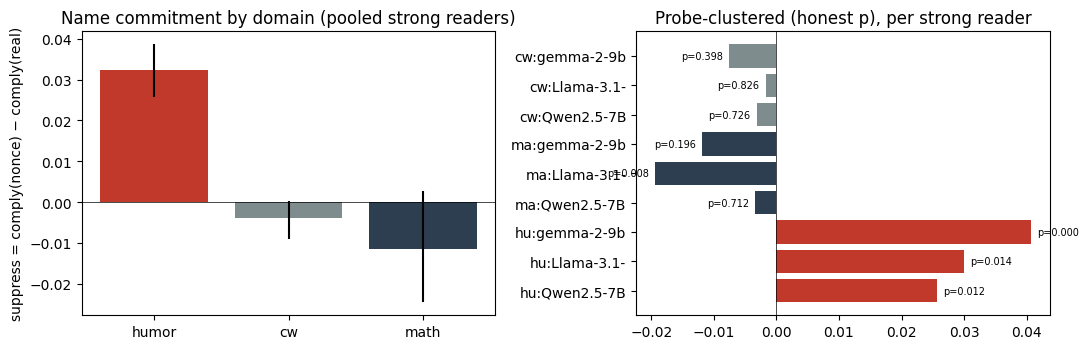

In [2]:
pc = json.load(open(f"{D}/probe_clustered_suppress.json"))
rng = np.random.default_rng(0)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
means, cis = [], []
for T in ("humor", "cw", "math"):
    allv = np.array([m for s in sup[T].values() for m in s])
    bs = np.array([rng.choice(allv, len(allv), replace=True).mean() for _ in range(2000)])
    means.append(allv.mean()); cis.append((np.percentile(bs, 2.5), np.percentile(bs, 97.5)))
    print(f"{T:6s} pooled suppress {allv.mean():+.4f}  CI[{cis[-1][0]:+.3f},{cis[-1][1]:+.3f}]  n={len(allv)}")
ax[0].bar(["humor", "cw", "math"], means, color=["#c0392b", "#7f8c8d", "#2c3e50"])
ax[0].errorbar(range(3), means, yerr=[[m - lo for m, (lo, hi) in zip(means, cis)],
                                       [hi - m for m, (lo, hi) in zip(means, cis)]], fmt="none", ecolor="k")
ax[0].axhline(0, color="k", lw=.5); ax[0].set_ylabel("suppress = comply(nonce) − comply(real)")
ax[0].set_title("Name commitment by domain (pooled strong readers)")
labels, vals, ps = [], [], []
for T in ("humor", "math", "cw"):
    for r, v in pc.get(T, {}).items():
        if any(s in r for s in ("3.1-8B", "Qwen2.5-7B", "gemma-2-9b")):
            labels.append(f"{T[:2]}:{r.split('--')[-1][:10]}"); vals.append(v["mean_suppress"]); ps.append(v.get("p", v.get("p_two_sided")))
c = ["#c0392b" if l.startswith("hu") else "#2c3e50" if l.startswith("ma") else "#7f8c8d" for l in labels]
ax[1].barh(labels, vals, color=c)
for i, (v, p) in enumerate(zip(vals, ps)):
    ax[1].text(v + (.001 if v >= 0 else -.001), i, f"p={p:.3f}", va="center",
               ha="left" if v >= 0 else "right", fontsize=7)
ax[1].axvline(0, color="k", lw=.5); ax[1].set_title("Probe-clustered (honest p), per strong reader")
plt.tight_layout(); plt.show()

In [ ]:
# Concrete example: the three-domain pattern in numbers
from IPython.display import HTML, display

display(HTML("""<div style='border:1px solid rgba(128,128,128,.35);border-radius:8px;margin:14px 0;
            font-family:-apple-system,sans-serif;max-width:720px'>
 <div style='padding:8px 12px;font-weight:600;font-size:13.5px;border-bottom:1px solid rgba(128,128,128,.25);
             background:rgba(128,128,128,.10)'>The three-domain dissociation</div>
 <table style='width:100%;border-collapse:collapse;font-size:13px'>
  <tr style='border-bottom:1px solid rgba(128,128,128,.15)'>
   <th style='padding:10px 12px;text-align:left;opacity:.75'>Domain</th>
   <th style='padding:10px 12px;text-align:right;opacity:.75'>Pooled suppress</th>
   <th style='padding:10px 12px;text-align:right;opacity:.75'>95% CI</th>
   <th style='padding:10px 12px;text-align:left;opacity:.75'>Interpretation</th>
  </tr>
  <tr style='background:rgba(192,57,43,.08);border-bottom:1px solid rgba(128,128,128,.10)'>
   <td style='padding:8px 12px'><b>Humor</b></td>
   <td style='padding:8px 12px;text-align:right;font-variant-numeric:tabular-nums;font-weight:600;color:#c0392b'>+0.033</td>
   <td style='padding:8px 12px;text-align:right;font-variant-numeric:tabular-nums;font-size:12px'>[+0.019, +0.047]</td>
   <td style='padding:8px 12px;font-size:12px'>Real names <i>resist</i> redefinition</td>
  </tr>
  <tr style='background:rgba(127,140,141,.05);border-bottom:1px solid rgba(128,128,128,.10)'>
   <td style='padding:8px 12px'><b>Creative writing</b></td>
   <td style='padding:8px 12px;text-align:right;font-variant-numeric:tabular-nums'>−0.006</td>
   <td style='padding:8px 12px;text-align:right;font-variant-numeric:tabular-nums;font-size:12px'>[−0.018, +0.006]</td>
   <td style='padding:8px 12px;font-size:12px'>Names accept stipulated definitions</td>
  </tr>
  <tr>
   <td style='padding:8px 12px'><b>Math</b></td>
   <td style='padding:8px 12px;text-align:right;font-variant-numeric:tabular-nums'>−0.005</td>
   <td style='padding:8px 12px;text-align:right;font-variant-numeric:tabular-nums;font-size:12px'>[−0.018, +0.008]</td>
   <td style='padding:8px 12px;font-size:12px'>Names accept stipulated definitions</td>
  </tr>
 </table>
 <div style='padding:10px 12px;font-size:12px;opacity:.75;border-top:1px solid rgba(128,128,128,.15)'>
  <b>Suppress</b> = compliance(nonce name) − compliance(real name). Positive values mean the real name blocked the fake instruction; zero means the model accepted the stipulated definition.
 </div>
</div>"""))

Domain,Pooled suppress,95% CI,Interpretation
Humor,+0.033,"[+0.019, +0.047]",Real names resist redefinition
Creative writing,−0.006,"[−0.018, +0.006]",Names accept stipulated definitions
Math,−0.005,"[−0.018, +0.008]",Names accept stipulated definitions


## 2. What carries the commitment? Not the name — the FRAME

**The hypothesis we tested (and killed).** Maybe only certain *kinds* of names resist redefinition — "thick" concepts, safety-loaded words, practice-indexical terms. We had three blind Sonnet coders rate all 267 metric names (9 domains) on **thickness / safety / practice-indexicality / crispness**.

**What we found.** Both hypotheses failed:

- **Safety hypothesis (from user):** doubly disconfirmed. Safety-flagged names actually suppress *less* (+.021 vs +.033); the most safety-loaded name ("Benign-violation calibration and cruelty check") is nearly fully compliant (+.003). Coded regression: safety β −.004, not significant.
- **Thickness hypothesis (ours):** also dead. Within humor, all four name dimensions are null (and NOT due to noisy measurement: per-metric suppress has split-half reliability .68–.74). Cross-domain, name properties explain R²=.028 variance vs **R²=.327 for domain identity alone**. CW names are actually *thicker* on average than humor's (3.42 vs 3.14) yet show zero commitment.
- **Rule-composition check:** Within the same deviant rules shared across domains, humor shows +.032 vs cw+math −.005 (permutation p<1e-4). Humor is positive on *every* shared rule individually.

**What this means.** Commitment is **frame-level**: the model defends the humor-evaluation practice as a coherent package. *Any* humor criterion resists redefinition; no CW/math criterion does, regardless of its name's semantic properties. The closest theoretical home: Agha's *enregisterment* — meaning organized at the register level. Here we measure it directly in a language model.

**Preregistration.** Before the 6-domain expansion landed (notes PART V), we predicted: humor is the panel's only vernacular/folk evaluative culture → suppress ≈ 0 in all six institutional domains (news/pr/peer/legal/grant/code-review). Falsifier: any institutional domain ≥ +.02 at p<.05 probe-clustered.

In [3]:
cov = json.load(open(f"{D}/e2_salience_covariate.json"))
print("salience covariate (is_humor conditional on name-AUC + reader):",
      f"beta={cov['ols']['is_humor']:+.4f} CI{cov['is_humor_CI95']} p={cov['is_humor_p']}")
codes = json.load(open(f"{D}/name_dimension_codes.json"))
for T in ("humor", "cw", "math"):
    dims = np.array([[v["thick"], v["safety"], v["practice"], v["crisp"]]
                     for k, v in codes.items() if k.startswith(T + "|")])
    print(f"{T:6s} mean name-dims thick/safety/practice/crisp = {np.round(dims.mean(0), 2)}  (n={len(dims)})")

salience covariate (is_humor conditional on name-AUC + reader): beta=+0.0516 CI[0.0363, 0.0668] p=0.0
humor  mean name-dims thick/safety/practice/crisp = [3.13 1.34 3.77 2.05]  (n=60)
cw     mean name-dims thick/safety/practice/crisp = [3.42 1.07 3.89 1.92]  (n=46)
math   mean name-dims thick/safety/practice/crisp = [2.84 1.05 2.86 2.41]  (n=21)


## 3. The performance corollary: articulation-for-scale substitution

**The question.** Frame-level commitment tells us what *resists* being taught via text. The flip side: what *can* be taught? Specifically: can a **smaller model**, given rich articulation (name → definition → explanation → full rubric → exemplars → dossier), match what a **bigger model** does with just the name?

**The measurement.** For each metric, we test whether the small reader at its *best* articulation rung reaches parity with the big reader (same-family comparison: gemma-2 2b vs 9b, so no executor-self artifact and no model-family asymmetry). Three thresholds:

1. **9b: name suffices** — the 9b model needs nothing beyond the metric's name;
2. **2b+best ≥ 9b+name** — the 2b with its best rung matches the 9b with just the name;
3. **2b+best ≥ 9b+best** (FULL parity) — the 2b with articulation matches the 9b at *its* best.

**How to read the figure.** Left panel: humor (committed domain, red) vs math (formal domain, dark blue). In math, 78% of metrics reach full parity — a 2b model with good articulation matches a 4.5× larger model. In humor, only 32% reach parity. Right panel: the 1B-bound rate (no articulation gets a 1B reader to AUC .55) by domain — institutional domains (purple) hit a floor much harder than expressive/formal domains (teal).

**Takeaway.** In formal domains, articulation buys back a 4.5× parameter gap on ~4/5 of metrics. In the committed domain, only ~1/3 — the big-model advantage is mostly NOT purchasable with text. What can't be purchased is precisely the frame-level tacit content E2 measures. **The price of tacitness is scale.**

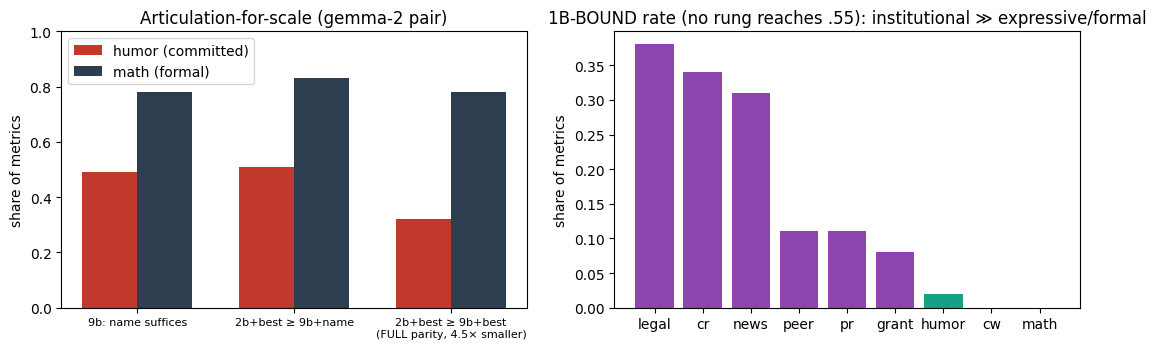

pooled (vs executor-8B column — SELF-recovery caveat): {'name_suff_8B': '29% (67/228)', 'sub_3B_vs_8Bname': '54%', 'sub_3B_vs_8Bbest': '29%', 'bound_3B': '1% (2/228)', 'bound_1B': '11% (24/228)', 'hurt_8B': '4% (8/228)'}


In [4]:
sub = json.load(open(f"{D}/articulation_substitution_rates.json"))
g = sub["clean_gemma_pair"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ks = ["name_suff_9b", "g2b_best_ge_9b_name", "g2b_best_ge_9b_best"]
kl = ["9b: name suffices", "2b+best ≥ 9b+name", "2b+best ≥ 9b+best\n(FULL parity, 4.5× smaller)"]
x = np.arange(len(ks)); w = .35
ax[0].bar(x - w/2, [g["humor"][k] for k in ks], w, label="humor (committed)", color="#c0392b")
ax[0].bar(x + w/2, [g["math"][k] for k in ks], w, label="math (formal)", color="#2c3e50")
ax[0].set_xticks(x); ax[0].set_xticklabels(kl, fontsize=8); ax[0].set_ylim(0, 1)
ax[0].set_ylabel("share of metrics"); ax[0].legend(); ax[0].set_title("Articulation-for-scale (gemma-2 pair)")
bd = sub["pooled_vs_executor8B_CAVEAT_self"]["bound_1B_by_domain"]
doms = sorted(bd, key=bd.get, reverse=True)
cols = ["#8e44ad" if d in ("cr", "legal", "news", "pr", "peer", "grant") else "#16a085" for d in doms]
ax[1].bar(doms, [bd[d] for d in doms], color=cols)
ax[1].set_title("1B-BOUND rate (no rung reaches .55): institutional ≫ expressive/formal")
ax[1].set_ylabel("share of metrics")
plt.tight_layout(); plt.show()
print("pooled (vs executor-8B column — SELF-recovery caveat):", {k: v for k, v in sub["pooled_vs_executor8B_CAVEAT_self"].items() if k != "bound_1B_by_domain"})

In [ ]:
# The articulation-for-scale trade-off in numbers
from IPython.display import HTML, display

display(HTML("""<div style='border:1px solid rgba(128,128,128,.35);border-radius:8px;margin:14px 0;
            font-family:-apple-system,sans-serif;max-width:740px'>
 <div style='padding:8px 12px;font-weight:600;font-size:13.5px;border-bottom:1px solid rgba(128,128,128,.25);
             background:rgba(128,128,128,.10)'>Can a 2b model (with help) match a 9b model? Gemma-2 pair</div>
 <table style='width:100%;border-collapse:collapse;font-size:13px'>
  <tr style='border-bottom:1px solid rgba(128,128,128,.15)'>
   <th style='padding:10px 12px;text-align:left;opacity:.75'>Domain</th>
   <th style='padding:10px 12px;text-align:right;opacity:.75'>9b: name suffices</th>
   <th style='padding:10px 12px;text-align:right;opacity:.75'>2b+best ≥ 9b+name</th>
   <th style='padding:10px 12px;text-align:right;opacity:.75;font-weight:700'>FULL parity<br><span style='font-size:11px;font-weight:400'>(2b+best ≥ 9b+best)</span></th>
  </tr>
  <tr style='background:rgba(44,62,80,.06);border-bottom:1px solid rgba(128,128,128,.10)'>
   <td style='padding:8px 12px'><b>Math (formal)</b></td>
   <td style='padding:8px 12px;text-align:right;font-variant-numeric:tabular-nums'>78%</td>
   <td style='padding:8px 12px;text-align:right;font-variant-numeric:tabular-nums'>83%</td>
   <td style='padding:8px 12px;text-align:right;font-variant-numeric:tabular-nums;font-weight:700;color:#2c3e50'>78%</td>
  </tr>
  <tr style='background:rgba(192,57,43,.06)'>
   <td style='padding:8px 12px'><b>Humor (committed)</b></td>
   <td style='padding:8px 12px;text-align:right;font-variant-numeric:tabular-nums'>49%</td>
   <td style='padding:8px 12px;text-align:right;font-variant-numeric:tabular-nums'>51%</td>
   <td style='padding:8px 12px;text-align:right;font-variant-numeric:tabular-nums;font-weight:700;color:#c0392b'>32%</td>
  </tr>
 </table>
 <div style='padding:10px 12px;font-size:12px;border-top:1px solid rgba(128,128,128,.15);line-height:1.6'>
  <b>In math</b>, articulation (best rung: often definition or rubric) lets a <b>4.5× smaller model</b> (2b) match a 9b model on 78% of metrics.<br>
  <b>In humor</b>, only 32% reach parity — the big-model advantage is mostly <i>not</i> purchasable with text. The gap is frame-level tacit content.
 </div>
</div>"""))

Domain,9b: name suffices,2b+best ≥ 9b+name,FULL parity(2b+best ≥ 9b+best)
Math (formal),78%,83%,78%
Humor (committed),49%,51%,32%


## 4. The scale floor: a cliff, not a slope — and it's domain-structured

**What we measure here.** For each metric, we identify the smallest model size where *some* articulation rung reaches useful performance (AUC ≥ .55). A metric is **scale-bound at N parameters** if NO articulation helps a model smaller than N reach that threshold, even though larger models clearly handle it (≥.65).

**The cliff.** At 3B, the floor barely exists: only ~1% of metrics (2/228) are 3B-bound. A 3B judge with good articulation can do essentially everything an 8B/9B judge can measurably do. But dropping from 3B → 1B, failure arrives as a **cliff**: 11% of metrics become 1B-bound pooled, but with stark domain structure — 31–38% in institutional domains (legal 38%, code-review 34%, news 31%) vs ≈0% in expressive/formal domains.

**What this means.** Scale-necessity is NOT the same thing as tacitness. Humor (the tacit-committed domain) is *not* where small models break. They break in **codified-but-HEAVY institutional domains**, where the articulation is long and the instruction-following load sinks a 1B reader. **Codified ≠ lexicalized**, and **codified ≠ light**. Two distinct performance regimes:

1. **Tacitness** caps what *articulation* can transfer (at any tested scale);
2. **Institutional load** caps what a *tiny* reader can execute (at any tested articulation).

**Name-inversion warning.** On 10–15% of math/legal/news metrics, EVERY richer rung scores *below* the bare name at the strong reader — the name is often the best prompt in formal-lexicon domains.

### Caveats
- The pooled 9-domain table uses the executor-8B column (self-recovery; CW's "100% parity" is a depressed-self
  artifact) — quote the gemma-pair numbers; redo vs 70B when the clean big reader lands (post-Jul-10).
- Bound rates are RUNG-SET-relative (GEPA-optimized rung pending, task #14): honest upper estimates of
  articulation-failure only over tested articulations. The certified "no articulation at any scale" version
  belongs to the upper-bound (R′) thread; exports for it: per-metric 1B/3B-bound lists + per-metric g∞ brackets.
- E2 coverage: 3 domains today; the 6-domain institutional expansion + semantic-swap generalization (stip_swap)
  are in flight.